## 1. タイトル・説明（Markdown）
# Fold-wise CMI Evaluation

このノートブックは、クロスバリデーションの各foldで保存されたモデルを使って、検証データに対するCMI値を計算します。

## 目的
- 各foldのモデルの性能を個別に評価
- foldごとのCMIスコアのばらつきを確認
- 可視化で使用するcv_results.jsonの生成

## 2. 必要なライブラリのインポート


In [1]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# プロジェクトのルートディレクトリをPATHに追加
import sys
sys.path.append('..')

from src.utils.cmi_evaluation import calculate_cmi_score
from src.trainers.multimodal_trainer_v40 import MultimodalTrainerV40

2025-07-22 15:06:02.844797: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-22 15:06:02.888776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753164362.909061  710169 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753164362.915327  710169 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753164362.934125  710169 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 3. 設定


In [2]:
# 設定
EXPERIMENT_NAME = "preprocess_v40_ws128"  # 評価したい実験名
N_SPLITS = 5
RANDOM_STATE = 42

# パス設定
BASE_DIR = Path(f"../output/experiments/{EXPERIMENT_NAME}")
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
PREPROCESSED_DIR = BASE_DIR / "preprocessed"

print(f"実験名: {EXPERIMENT_NAME}")
print(f"ベースディレクトリ: {BASE_DIR}")
print(f"CVのfold数: {N_SPLITS}")

実験名: preprocess_v40_ws128
ベースディレクトリ: ../output/experiments/preprocess_v40_ws128
CVのfold数: 5


In [3]:
print("📊 データを読み込み中...")

# MultimodalTrainerV40を使用してデータを読み込み
trainer = MultimodalTrainerV40(EXPERIMENT_NAME)
trainer.data_dir = Path(f"../output/experiments/{EXPERIMENT_NAME}/preprocessed")
data = trainer.load_all_data()

X_sensor = data['sensor']
X_demo = data['demographics']
X_tab = data['tabular']
y = data['labels']
groups = data['groups']

print(f"✅ データ読み込み完了")
print(f"  - センサーデータ: {X_sensor.shape}")
print(f"  - デモグラフィックデータ: {X_demo.shape}")
print(f"  - タブラーデータ: {X_tab.shape}")
print(f"  - ラベル: {y.shape}")
print(f"  - グループ数: {len(np.unique(groups))}")

📊 データを読み込み中...
Experiment name: preprocess_v40_ws128
Data directory: output/experiments/preprocess_v40_ws128/preprocessed
前処理済みデータを読み込み中...
センサー: (20294, 64, 18)
人口統計: (20294, 7)
表形式: (20294, 429)
ToF: (20294, 64, 5, 8, 8)
ラベル: (20294,)
グループ数: 20294
✅ データ読み込み完了
  - センサーデータ: (20294, 64, 18)
  - デモグラフィックデータ: (20294, 7)
  - タブラーデータ: (20294, 429)
  - ラベル: (20294,)
  - グループ数: 162


## 5. クロスバリデーション分割


In [4]:
print("\n🔄 クロスバリデーション分割を再現中...")

skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf.split(X_sensor, y, groups))

print(f"✅ {N_SPLITS}つのfoldを生成")

# 各foldの情報を表示
for i, (train_idx, val_idx) in enumerate(folds):
    train_size = len(train_idx)
    val_size = len(val_idx)
    print(f"  Fold {i+1}: 訓練={train_size:,}, 検証={val_size:,}")


🔄 クロスバリデーション分割を再現中...
✅ 5つのfoldを生成
  Fold 1: 訓練=16,555, 検証=3,739
  Fold 2: 訓練=16,242, 検証=4,052
  Fold 3: 訓練=16,455, 検証=3,839
  Fold 4: 訓練=16,075, 検証=4,219
  Fold 5: 訓練=15,849, 検証=4,445


In [5]:

from src.utils.cmi_evaluation import TARGET_GESTURES, NON_TARGET_GESTURES

print("\n🎯 各foldのモデルを評価中...")

# ラベルID→行動名の辞書
label2gesture = {i: name for i, name in enumerate(TARGET_GESTURES + NON_TARGET_GESTURES)}
target_label_ids = set(i for i, name in label2gesture.items() if name in TARGET_GESTURES)

fold_results = []
all_predictions = []
all_true_labels = []

for fold, (train_idx, val_idx) in enumerate(folds):
    print(f"\n--- Fold {fold+1} ---")
    
    # モデルの読み込み
    model_path = MODELS_DIR / f"multimodal_model_v40_fold{fold+1}.keras"
    
    if not model_path.exists():
        print(f"⚠️  モデルファイルが見つかりません: {model_path}")
        continue
    
    try:
        model = tf.keras.models.load_model(model_path)
        print(f"✅ モデル読み込み完了: {model_path.name}")
    except Exception as e:
        print(f"❌ モデル読み込みエラー: {e}")
        continue
    
    # 検証データの準備
    X_val_sensor = X_sensor[val_idx]
    X_val_demo = X_demo[val_idx]
    X_val_tab = X_tab[val_idx]
    X_val_tof = data['tof'][val_idx]
    y_val = y[val_idx]
    
    # 予測
    print(f"📊 予測実行中... (検証データ数: {len(val_idx):,})")
    y_pred_proba = model.predict({
        'sensor': X_val_sensor,
        'demo': X_val_demo,
        'tabular': X_val_tab,
        'tof': X_val_tof
    }, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # メトリクス計算
    cmi_score = calculate_cmi_score(y_val, y_pred)
    if isinstance(cmi_score, tuple):
        cmi_score = cmi_score[0]
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    accuracy = np.mean(y_val == y_pred)
    
    # --- Binary F1（ターゲット/非ターゲット2値化） ---
    y_val_bin = np.array([1 if l in target_label_ids else 0 for l in y_val])
    y_pred_bin = np.array([1 if l in target_label_ids else 0 for l in y_pred])
    binary_f1 = f1_score(y_val_bin, y_pred_bin, average='binary', pos_label=1)
    
    # 結果を保存
    fold_result = {
        'fold': fold + 1,
        'cmi_score': float(cmi_score),
        'binary_f1': float(binary_f1),
        'macro_f1': float(macro_f1),
        'accuracy': float(accuracy),
        'val_size': len(val_idx)
    }
    
    fold_results.append(fold_result)
    all_predictions.extend(y_pred)
    all_true_labels.extend(y_val)
    
    print(f"  CMI Score: {cmi_score:.4f}")
    print(f"  Binary F1: {binary_f1:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")

print(f"\n✅ 全{len(fold_results)}フォルドの評価完了")


🎯 各foldのモデルを評価中...

--- Fold 1 ---


I0000 00:00:1753164386.223286  710169 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5660 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6


✅ モデル読み込み完了: multimodal_model_v40_fold1.keras
📊 予測実行中... (検証データ数: 3,739)


I0000 00:00:1753164388.357699  710311 cuda_dnn.cc:529] Loaded cuDNN version 90501


  CMI Score: 0.8218
  Binary F1: 0.9408
  Macro F1: 0.8218
  Accuracy: 0.7909

--- Fold 2 ---
✅ モデル読み込み完了: multimodal_model_v40_fold2.keras
📊 予測実行中... (検証データ数: 4,052)
  CMI Score: 0.5359
  Binary F1: 0.8416
  Macro F1: 0.5359
  Accuracy: 0.5252

--- Fold 3 ---
✅ モデル読み込み完了: multimodal_model_v40_fold3.keras
📊 予測実行中... (検証データ数: 3,839)
  CMI Score: 0.7972
  Binary F1: 0.9305
  Macro F1: 0.7972
  Accuracy: 0.7617

--- Fold 4 ---
✅ モデル読み込み完了: multimodal_model_v40_fold4.keras
📊 予測実行中... (検証データ数: 4,219)
  CMI Score: 0.7791
  Binary F1: 0.9291
  Macro F1: 0.7791
  Accuracy: 0.7585

--- Fold 5 ---
✅ モデル読み込み完了: multimodal_model_v40_fold5.keras
📊 予測実行中... (検証データ数: 4,445)
  CMI Score: 0.7059
  Binary F1: 0.8968
  Macro F1: 0.7059
  Accuracy: 0.6801

✅ 全5フォルドの評価完了


In [6]:
if not fold_results:
    print("❌ 評価結果がありません")
else:
    print("\n📈 結果の集計中...")

    df_results = pd.DataFrame(fold_results)

    # 統計情報
    stats = {
        'cmi_score': {
            'mean': df_results['cmi_score'].mean(),
            'std': df_results['cmi_score'].std(),
            'min': df_results['cmi_score'].min(),
            'max': df_results['cmi_score'].max()
        },
        'macro_f1': {
            'mean': df_results['macro_f1'].mean(),
            'std': df_results['macro_f1'].std(),
            'min': df_results['macro_f1'].min(),
            'max': df_results['macro_f1'].max()
        },
        'accuracy': {
            'mean': df_results['accuracy'].mean(),
            'std': df_results['accuracy'].std(),
            'min': df_results['accuracy'].min(),
            'max': df_results['accuracy'].max()
        }
    }

    print("\n📊 統計情報:")
    for metric, values in stats.items():
        print(f"  {metric.upper()}:")
        print(f"    平均: {values['mean']:.4f} ± {values['std']:.4f}")
        print(f"    範囲: [{values['min']:.4f}, {values['max']:.4f}]")

    # 詳細結果の表示
    print("\n📋 詳細結果:")
    display(df_results.round(4))


📈 結果の集計中...

📊 統計情報:
  CMI_SCORE:
    平均: 0.7280 ± 0.1157
    範囲: [0.5359, 0.8218]
  MACRO_F1:
    平均: 0.7280 ± 0.1157
    範囲: [0.5359, 0.8218]
  ACCURACY:
    平均: 0.7032 ± 0.1077
    範囲: [0.5252, 0.7909]

📋 詳細結果:


,fold,cmi_score,binary_f1,macro_f1,accuracy,val_size
0,1,0.8218,0.9408,0.8218,0.7909,3739
1,2,0.5359,0.8416,0.5359,0.5252,4052
2,3,0.7972,0.9305,0.7972,0.7617,3839
3,4,0.7791,0.9291,0.7791,0.7585,4219
4,5,0.7059,0.8968,0.7059,0.6801,4445


## 8. 結果の可視化



📊 結果を可視化中...


/tmp/ipykernel_710169/1196111730.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(metrics_data, labels=metrics_labels, patch_artist=True)


✅ 可視化結果を保存: ../output/experiments/preprocess_v40_ws128/results/fold_wise_evaluation.png


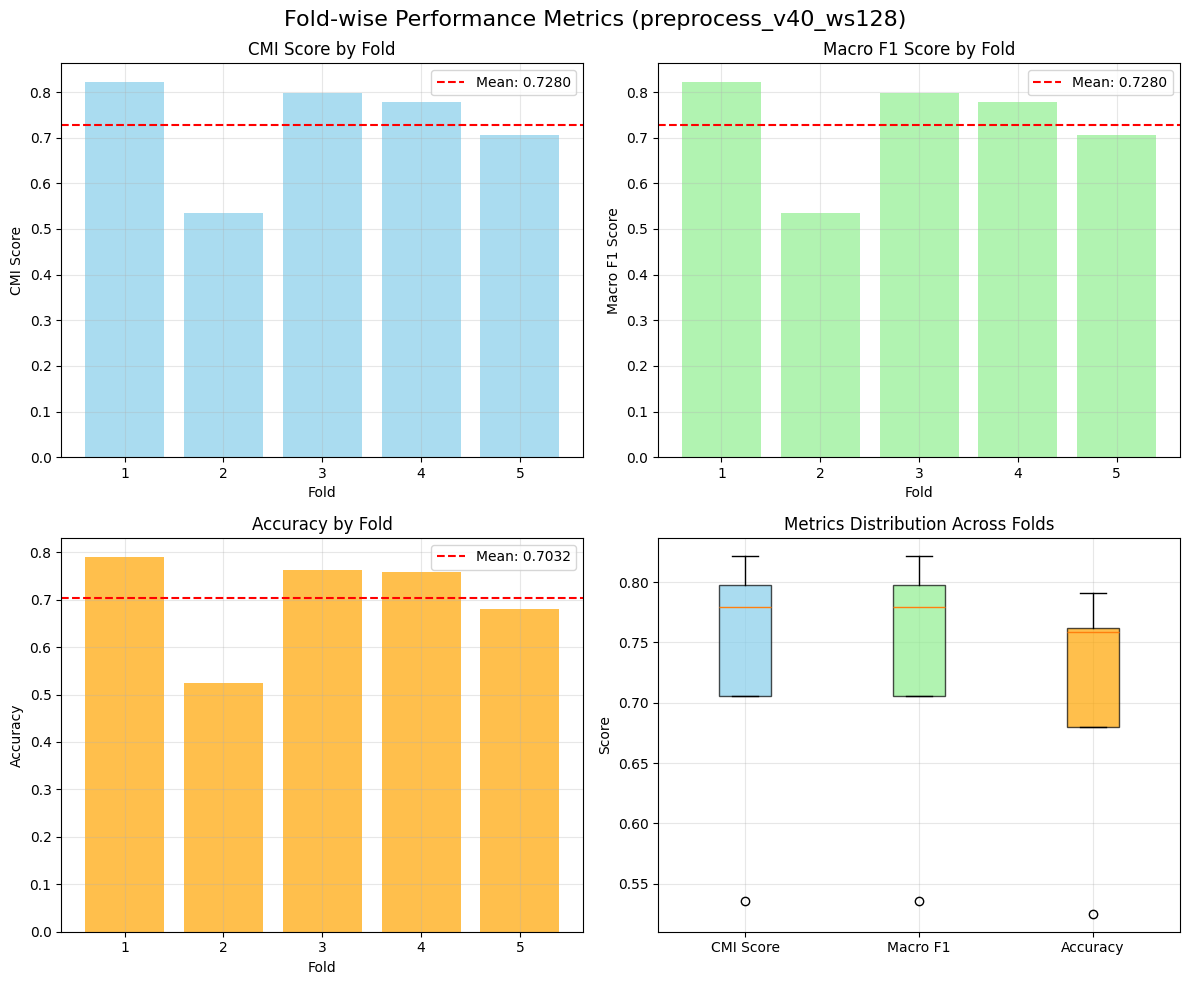

In [7]:
if fold_results:
    print("\n📊 結果を可視化中...")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Fold-wise Performance Metrics ({EXPERIMENT_NAME})', fontsize=16)

    # CMI Score
    axes[0, 0].bar(df_results['fold'], df_results['cmi_score'], color='skyblue', alpha=0.7)
    axes[0, 0].axhline(y=df_results['cmi_score'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df_results['cmi_score'].mean():.4f}")
    axes[0, 0].set_title('CMI Score by Fold')
    axes[0, 0].set_xlabel('Fold')
    axes[0, 0].set_ylabel('CMI Score')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Macro F1
    axes[0, 1].bar(df_results['fold'], df_results['macro_f1'], color='lightgreen', alpha=0.7)
    axes[0, 1].axhline(y=df_results['macro_f1'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df_results["macro_f1"].mean():.4f}')
    axes[0, 1].set_title('Macro F1 Score by Fold')
    axes[0, 1].set_xlabel('Fold')
    axes[0, 1].set_ylabel('Macro F1 Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Accuracy
    axes[1, 0].bar(df_results['fold'], df_results['accuracy'], color='orange', alpha=0.7)
    axes[1, 0].axhline(y=df_results['accuracy'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df_results["accuracy"].mean():.4f}')
    axes[1, 0].set_title('Accuracy by Fold')
    axes[1, 0].set_xlabel('Fold')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # メトリクスの分布
    metrics_data = [df_results['cmi_score'], df_results['macro_f1'], df_results['accuracy']]
    metrics_labels = ['CMI Score', 'Macro F1', 'Accuracy']

    bp = axes[1, 1].boxplot(metrics_data, labels=metrics_labels, patch_artist=True)
    colors = ['skyblue', 'lightgreen', 'orange']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[1, 1].set_title('Metrics Distribution Across Folds')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # 図の保存
    output_path = RESULTS_DIR / "fold_wise_evaluation.png"
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✅ 可視化結果を保存: {output_path}")

    plt.show()
    
    

In [8]:
if fold_results:
    print("\n💾 cv_results.jsonを生成中...")

    # 全体の平均を計算
    overall_cmi = calculate_cmi_score(all_true_labels, all_predictions)
    if isinstance(overall_cmi, tuple):
        overall_cmi = overall_cmi[0]
    overall_macro_f1 = f1_score(all_true_labels, all_predictions, average='macro')
    overall_accuracy = np.mean(np.array(all_true_labels) == np.array(all_predictions))

    cv_results = {
        'fold_cmi_scores': [result['cmi_score'] for result in fold_results],
        'fold_macro_f1_scores': [result['macro_f1'] for result in fold_results],
        'fold_accuracies': [result['accuracy'] for result in fold_results],
        'mean_cmi_score': float(np.mean([result['cmi_score'] for result in fold_results])),
        'std_cmi_score': float(np.std([result['cmi_score'] for result in fold_results])),
        'mean_macro_f1': float(np.mean([result['macro_f1'] for result in fold_results])),
        'std_macro_f1': float(np.std([result['macro_f1'] for result in fold_results])),
        'mean_accuracy': float(np.mean([result['accuracy'] for result in fold_results])),
        'std_accuracy': float(np.std([result['accuracy'] for result in fold_results])),
        'overall_cmi_score': float(overall_cmi),
        'overall_macro_f1': float(overall_macro_f1),
        'overall_accuracy': float(overall_accuracy),
        'n_folds': len(fold_results),
        'experiment_name': EXPERIMENT_NAME
    }

    # ファイルに保存
    cv_results_path = RESULTS_DIR / "cv_results.json"
    with open(cv_results_path, 'w') as f:
        json.dump(cv_results, f, indent=2)

    print(f"✅ cv_results.jsonを保存: {cv_results_path}")

    # 詳細結果も保存
    detailed_results_path = RESULTS_DIR / "fold_wise_detailed_results.json"
    with open(detailed_results_path, 'w') as f:
        json.dump(fold_results, f, indent=2)

    print(f"✅ 詳細結果を保存: {detailed_results_path}")

    # サマリーの表示
    print("\n📋 生成されたcv_results.jsonのサマリー:")
    print(f"  - foldごとのCMIスコア: {cv_results['fold_cmi_scores']}")
    print(f"  - 平均CMIスコア: {cv_results['mean_cmi_score']:.4f} ± {cv_results['std_cmi_score']:.4f}")
    print(f"  - 全体CMIスコア: {cv_results['overall_cmi_score']:.4f}")


💾 cv_results.jsonを生成中...
✅ cv_results.jsonを保存: ../output/experiments/preprocess_v40_ws128/results/cv_results.json
✅ 詳細結果を保存: ../output/experiments/preprocess_v40_ws128/results/fold_wise_detailed_results.json

📋 生成されたcv_results.jsonのサマリー:
  - foldごとのCMIスコア: [0.8217829633675579, 0.535909445735041, 0.7971692086411978, 0.7790870208043916, 0.7058506481099331]
  - 平均CMIスコア: 0.7280 ± 0.1035
  - 全体CMIスコア: 0.7256


## 10. 混同行列の可視化（オプション）



🎯 混同行列を生成中（Fold 1の例）...
✅ 混同行列を保存: ../output/experiments/preprocess_v40_ws128/results/confusion_matrix_fold1.png


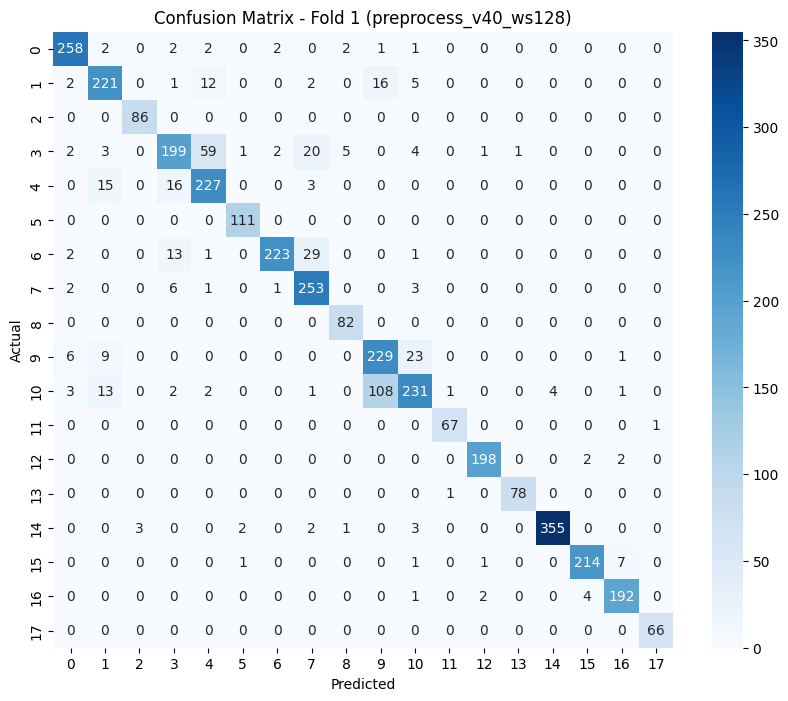


📊 分類レポート（Fold 1）:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       270
           1       0.84      0.85      0.85       259
           2       0.97      1.00      0.98        86
           3       0.83      0.67      0.74       297
           4       0.75      0.87      0.80       261
           5       0.97      1.00      0.98       111
           6       0.98      0.83      0.90       269
           7       0.82      0.95      0.88       266
           8       0.91      1.00      0.95        82
           9       0.65      0.85      0.74       268
          10       0.85      0.63      0.72       366
          11       0.97      0.99      0.98        68
          12       0.98      0.98      0.98       202
          13       0.99      0.99      0.99        79
          14       0.99      0.97      0.98       366
          15       0.97      0.96      0.96       224
          16       0.95      0.96      0.96       199
        

In [9]:
# 混同行列を出したい場合のみ実行
if fold_results:
    print("\n🎯 混同行列を生成中（Fold 1の例）...")

    # 最初のfoldのデータを使用
    train_idx, val_idx = folds[0]
    X_val_sensor = np.array(X_sensor[val_idx])
    X_val_demo = np.array(X_demo[val_idx])
    X_val_tab = np.array(X_tab[val_idx])
    X_val_tof = np.array(data['tof'][val_idx])
    # モデルの読み込み
    # model_path = MODELS_DIR / "model_fold_1.keras"
    model_path = MODELS_DIR / f"multimodal_model_v40_fold{fold+1}.keras"
    if model_path.exists():
        model = tf.keras.models.load_model(model_path)

        # 検証データの準備
        X_val_sensor = X_sensor[val_idx]
        X_val_demo = X_demo[val_idx]
        X_val_tab = X_tab[val_idx]
        y_val = y[val_idx]

        # 予測
        y_pred_proba = model.predict({
            'sensor': X_val_sensor,
            'demo': X_val_demo,
            'tabular': X_val_tab,
            'tof': X_val_tof  # 必要なら
        }, verbose=0)

        y_pred = np.argmax(y_pred_proba, axis=1)

        # 混同行列の作成
        cm = confusion_matrix(y_val, y_pred)

        # 可視化
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - Fold 1 ({EXPERIMENT_NAME})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        # 保存
        cm_path = RESULTS_DIR / "confusion_matrix_fold1.png"
        plt.savefig(cm_path, dpi=300, bbox_inches='tight')
        print(f"✅ 混同行列を保存: {cm_path}")

        plt.show()

        # 分類レポート
        print("\n📊 分類レポート（Fold 1）:")
        print(classification_report(y_val, y_pred))
    else:
        print(f"❌ モデルファイルが見つかりません: {model_path}")

## まとめ

- 各foldのモデルを個別に評価し、CMI・F1・Accuracyを計算
- foldごとのスコアのばらつきや分布を可視化
- cv_results.jsonを生成し、可視化スクリプト等で利用可能
- 混同行列や分類レポートも出力可能